In [4]:
import pandas as pd
data = pd.read_csv('houses.csv')

# display the first 5 rows of dataset
data.head()

,Square_Feet,Bedrooms,Price
0,1500,3,250000
1,2000,4,320000
2,1200,2,190000
3,2500,4,410000
4,1800,3,280000


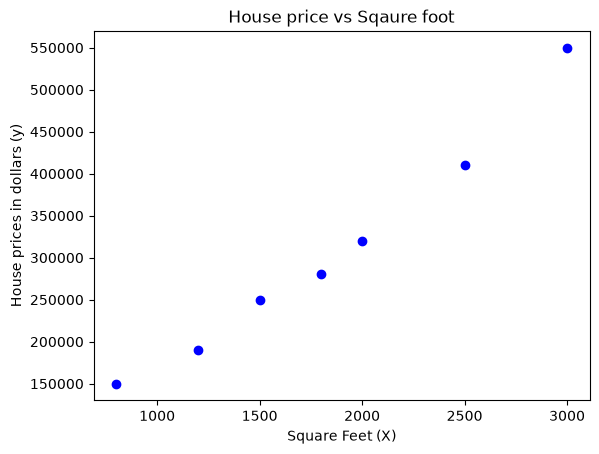

In [5]:
import matplotlib.pyplot as plt

# seprate our features (X - square feet, no.of rooms) from target (Y)
square_feet = data['Square_Feet']
bedrooms = data['Bedrooms']
price = data['Price']

# create a scatter plot
plt.scatter(square_feet, price, color='blue')

# Add labels to make it readable
plt.title('House price vs Sqaure foot')
plt.xlabel('Square Feet (X)')
plt.ylabel('House prices in dollars (y)')

# show the graph
plt.show()

In [11]:
w = 170 
b = -100

# 1. prediction (y_hat = wx + b)
# pandas smart enough to apply this to every single row
y_hat = (w * square_feet) + b
print(f"Y-pred: {y_hat}")
# calculate the differenct (Actual - Prediction)
error = price - y_hat 
squared_error = error ** 2

mse = squared_error.mean()

print(f"Your manual MSE is : {mse:,.2f}")

Y-pred: 0    254900
1    339900
2    203900
3    424900
4    305900
5    135900
6    509900
Name: Square_Feet, dtype: int64
Your manual MSE is : 473,267,142.86


In [12]:
# 1. Start with a terrible random guess
w = 0.0
b = 0.0

# 2. Hyperparameters( The settings for our algorithms)
# learning_rate is extremely tiny so our "blindfold hiker" 
# does not take massive leaps and accidentally jump over the valley

learning_rate = 0.0000001
epochs = 100 # How many total step hiker will take 

n = len(square_feet) # total_number of houses

# 3. Training loop (Waking down the mountains)

for i in range(epochs):
    # Step A: Make prediction with the current value of w and b
    y_hat = (w * square_feet) + b 
    
    # Step B: calculate the difference (Actual - Prediction)
    error = price - y_hat 
    # squared_error = error ** 2

    # Step C: the calculas (partial derivatives)
    w_gradient = -(2/n) * sum(square_feet * error)
    b_gradient = -(2/n) * sum(error)

    # Step D: update our w and b by taking a tiny step down the slope
    w = w - (learning_rate * w_gradient)
    b = b - (learning_rate * b_gradient)


# 4. Print the computer's final learned values!
print(f"The computer learned w = {w:.2f}")
print(f"The computer learned b = {b:.2f}")



The computer learned w = 169.35
The computer learned b = 0.03


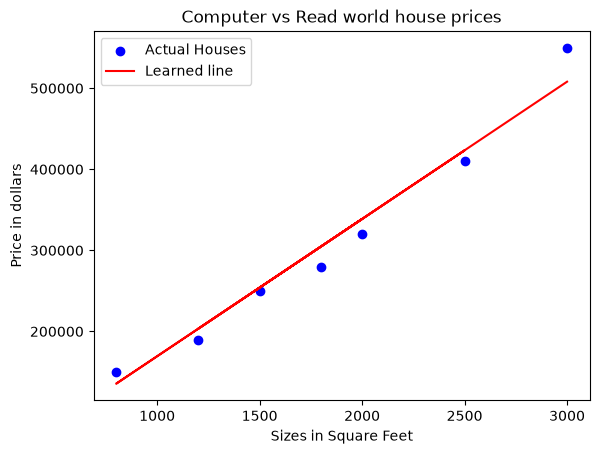

In [13]:
import matplotlib.pyplot as plt

# 1. Re-draw the scatter plot of actual data
plt.scatter(square_feet, price, color='blue', label='Actual Houses')

# 2. Calculate the line using the computer's learned w and b
predicted_prices = (w * square_feet) + b 

# Draw the computer's prediction line in red 
plt.plot(square_feet, predicted_prices, color='red', label='Learned line')

# Add labels and a legend so we know what is what 
plt.title('Computer vs Read world house prices')
plt.xlabel('Sizes in Square Feet')
plt.ylabel('Price in dollars')
plt.legend()

plt.show()

In [14]:
from sklearn.linear_model import LinearRegression

# 1. Prepare the data
# Scikit-learn expects X (features) to be a 2D table (even if it's just one column)
# Double brackets [['Square_Feet']] keeps it as a 2D Pandas table instead of a 1D list
X = data[['Square_Feet']] 
y = data['Price']

# 2. Create the "Brain" (This is an empty model, waiting to learn)
model = LinearRegression()

# 3. Train the model (This ONE line does all the calculus and looping we wrote earlier!)
model.fit(X, y)

# 4. Check the results
print(f"Scikit-Learn found w = {model.coef_[0]:.2f}")
print(f"Scikit-Learn found b = {model.intercept_:.2f}")

Scikit-Learn found w = 178.83
Scikit-Learn found b = -19857.74
